# 2.Feature Selection -With Correlation


##### In this step we will be removing the features which are highly correlated

In [9]:
import sys
print(sys.executable)
from sklearn.datasets import fetch_california_housing
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

c:\Users\aryan\Envs\learn_project\Scripts\python.exe


In [10]:
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['MedHouseVal']=data.target
data.feature_names #independent feature

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [11]:
data.feature_names #independent feature

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [12]:
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [13]:
y.head()

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64

In [14]:
# separate dataset into train and test
from sklearn.model_selection import train_test_split
# if we do train split so it prevent from overfitting 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
X_train.shape,X_test.shape


((14448, 8), (6192, 8))

In [15]:
X_train.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
MedInc,1.000000,-0.120396,0.358747,-0.059383,0.006284,0.002043,-0.085176,-0.010093
HouseAge,-0.120396,1.000000,-0.162349,-0.077218,-0.299736,0.013631,0.020830,-0.117501
AveRooms,0.358747,-0.162349,1.000000,0.825325,-0.068784,0.005120,0.105380,-0.025010
AveBedrms,-0.059383,-0.077218,0.825325,1.000000,-0.060845,-0.002736,0.068443,0.013283
Population,0.006284,-0.299736,-0.068784,-0.060845,1.000000,0.074734,-0.117704,0.108161
AveOccup,0.002043,0.013631,0.005120,-0.002736,0.074734,1.000000,-0.003676,0.012906
Latitude,-0.085176,0.020830,0.105380,0.068443,-0.117704,-0.003676,1.000000,-0.925158
Longitude,-0.010093,-0.117501,-0.025010,0.013283,0.108161,0.012906,-0.925158,1.000000


<Axes: >

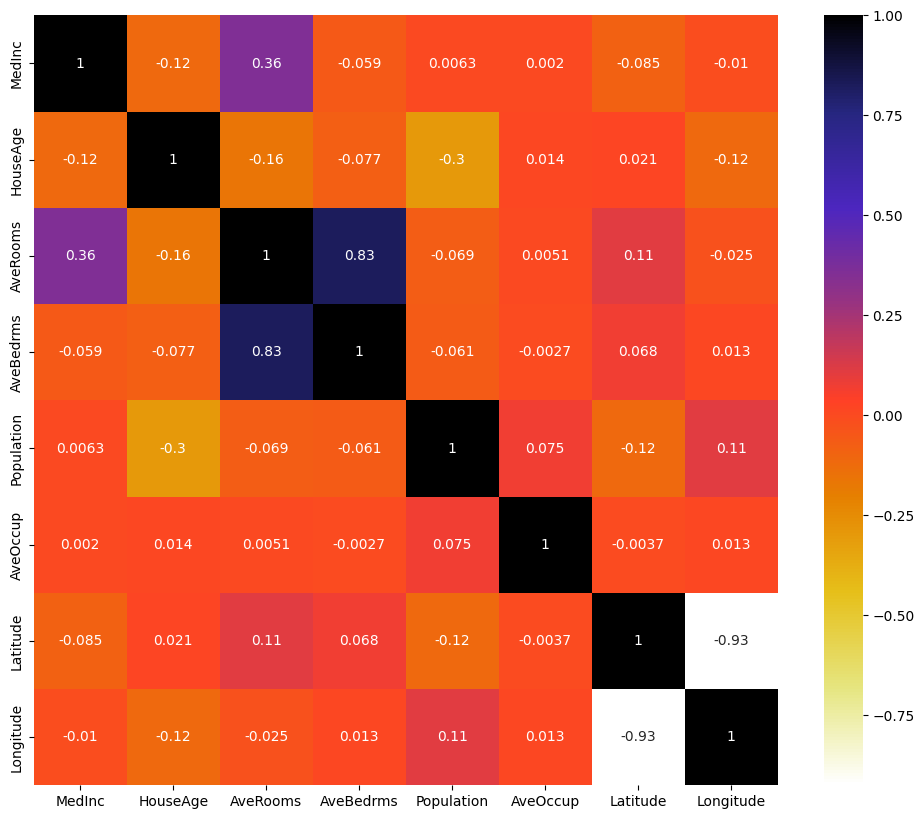

In [16]:
import seaborn as sns
#Using Pearson Correlation
plt.figure(figsize=(12,10))
cor=X_train.corr()
sns.heatmap(cor, annot=True,cmap=plt.cm.CMRmap_r)


In [34]:
# with the following function we can select highly correlated features
# it will remove the first feature that is correlated with anything other feature

def correlation(dataset, threshold):
    col_corr = set() # Set of all the names of deleted columns
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold: # we are interested in absolute coeff value > 0.8
                colname = corr_matrix.columns[i] # getting the name of column
                col_corr.add(colname)
    return col_corr

In [36]:
corr_features = correlation(X_train, 0.7)
len(set(corr_features))


2

In [37]:
corr_features  

{'AveBedrms', 'Longitude'}

In [38]:
X_train.drop(labels=corr_features, axis=1)          
X_test.drop(labels=corr_features, axis=1)

,MedInc,HouseAge,AveRooms,Population,AveOccup,Latitude
14740,4.1518,22.0,5.663073,1551.0,4.180593,32.58
10101,5.7796,32.0,6.107226,1296.0,3.020979,33.92
20566,4.3487,29.0,5.930712,1554.0,2.910112,38.65
2670,2.4511,37.0,4.992958,390.0,2.746479,33.20
15709,5.0049,25.0,4.319261,649.0,1.712401,37.79
...,...,...,...,...,...,...
19681,3.0962,36.0,4.746421,1168.0,2.388548,39.15
12156,4.1386,2.0,8.821216,2826.0,3.368296,33.66
10211,7.8750,30.0,7.550926,523.0,2.421296,33.89
2445,2.0658,34.0,5.938144,363.0,3.742268,36.56
